CMEMS Dataset https://data.marine.copernicus.eu/product/SEALEVEL_GLO_PHY_L4_MY_008_047/description
Handmatig gedownload vanaf MyOcean Pro, aanklikken punt in de ocean (grof gekozen bij Vlissingen en Ijmuiden) maar informatie in de readme

In [1]:
import pandas as pd
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib as Path
Path = Path.Path

folder = Path.cwd()
output_dir = folder / "output"

csv = r'C:\projecten\RWS\sealevelmonitor\data\copernicus\satellite\cmems_obs-sl_glo_phy-ssh_my_allsat-demo-l4-duacs-0.125deg_P1D-i_1784027499090.csv' #dichtbij ijmuiden
df = pd.read_csv(csv,comment="#")

In [2]:
output_dir

WindowsPath('c:/projecten/RWS/sealevelmonitor/validation/satelllite/output')

In [3]:
df = df.rename(columns={'adt':'value'})
df['time'] = pd.to_datetime(df['time'], format='%Y-%m-%dT%H:%M:%S.%fZ')

x = (df['time'] - df['time'].iloc[0]).dt.days / 365.25 # years since start
y = df["value"]

result = linregress(x, y)
print(f"Trend = {result.slope:.4f} m/year")


Trend = 0.0039 m/year


Slope: 0.0038073481364066385, Intercept: -7.540083258572987


C:\Users\dees\AppData\Local\Temp\ipykernel_30924\4215388585.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_yearly = df.groupby(df['time'].dt.year).mean()


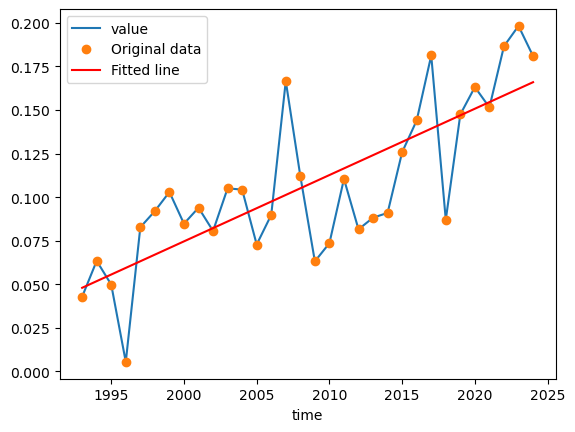

In [ ]:
df_yearly = df.groupby(df['time'].dt.year).mean()

x = df_yearly.index
y = df_yearly['value']
result = linregress(x, y)
slope = result.slope
intercept = result.intercept
print(f"Slope: {slope}, Intercept: {intercept}")

# Plot the regression line
import matplotlib.pyplot as plt
plt.plot(x, y, 'o', label='Original data')
plt.plot(x, slope*x + intercept, 'r', label='Fitted line')
plt.legend()
plt.show()


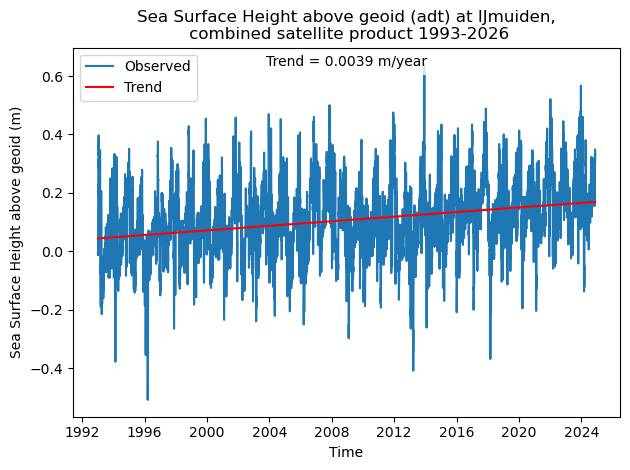

In [17]:
trend = result.intercept + result.slope * x

plt.plot(df['time'], y)
plt.plot(df['time'], trend, color="red")
plt.title("Sea Surface Height above geoid (adt) at IJmuiden,\n combined satellite product 1993-2026")
plt.xlabel("Time")
plt.ylabel("Sea Surface Height above geoid (m)")
plt.legend(["Observed", "Trend"])

plt.text(
    0.5, 0.98,
    f"Trend = {result.slope:.4f} m/year",
    transform=plt.gca().transAxes,
    ha="center",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

plt.tight_layout()
plt.savefig(output_dir / "sea_surface_height_trend_ijmuiden.png", dpi=300)
plt.show()

In [24]:
csv = r'C:\projecten\RWS\sealevelmonitor\data\copernicus\satellite\cmems_obs-sl_glo_phy-ssh_my_allsat-demo-l4-duacs-0.125deg_P1D-i_1784027499101.csv' #dichtbij vlissingen
df = pd.read_csv(csv,comment="#")

Trend = 0.0046 m/year


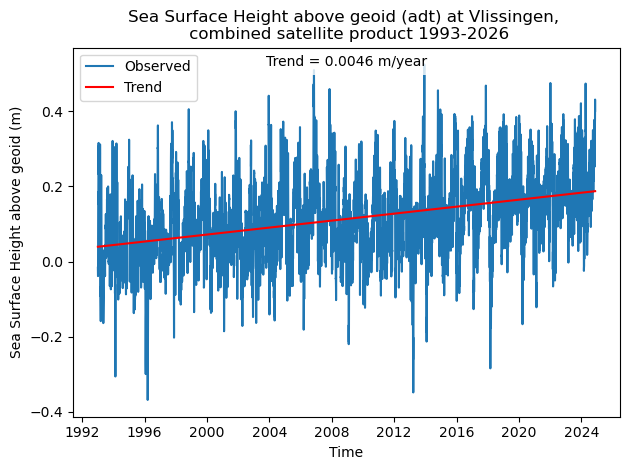

In [25]:
dfv = df.rename(columns={'adt':'value'})
dfv['time'] = pd.to_datetime(dfv['time'], format='%Y-%m-%dT%H:%M:%S.%fZ')

x = (dfv['time'] - dfv['time'].iloc[0]).dt.days / 365.25 # years since start
y = dfv["value"]

result = linregress(x, y)
print(f"Trend = {result.slope:.4f} m/year")
trend = result.intercept + result.slope * x

plt.plot(dfv['time'], y)
plt.plot(dfv['time'], trend, color="red")
plt.title("Sea Surface Height above geoid (adt) at Vlissingen, \n combined satellite product 1993-2026")
plt.xlabel("Time")
plt.ylabel("Sea Surface Height above geoid (m)")
plt.legend(["Observed", "Trend"])
plt.text(
    0.5, 0.98,
    f"Trend = {result.slope:.4f} m/year",
    transform=plt.gca().transAxes,
    ha="center",
    va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)
plt.tight_layout()
plt.savefig(output_dir / "sea_surface_height_trend_vlissingen.png", dpi=300)    
plt.show()

Slope: 0.00455182946449166, Intercept: -9.028513238203912


C:\Users\dees\AppData\Local\Temp\ipykernel_30924\1838988414.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  dfv_yearly = dfv.groupby(dfv['time'].dt.year).mean()


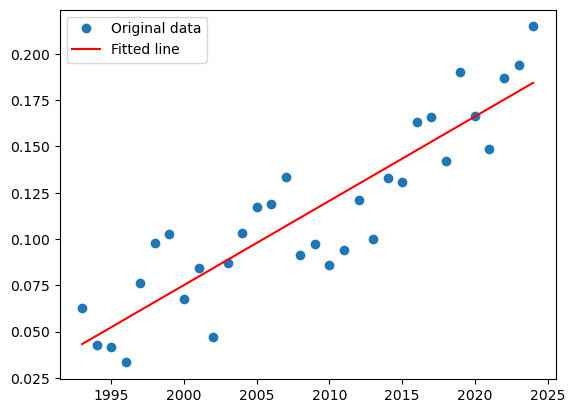

In [27]:
dfv_yearly = dfv.groupby(dfv['time'].dt.year).mean()

x = dfv_yearly.index
y = dfv_yearly['value']
result = linregress(x, y)
slope = result.slope
intercept = result.intercept
print(f"Slope: {slope}, Intercept: {intercept}")

# Plot the regression line
import matplotlib.pyplot as plt
plt.plot(x, y, 'o', label='Original data')
plt.plot(x, slope*x + intercept, 'r', label='Fitted line')
plt.legend()
plt.show()
